In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [23]:
(x_train, _), (x_test, _) = mnist.load_data()

In [24]:
print("Training Images:", x_train.shape)
print("Testing Images:", x_test.shape)

Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


In [25]:
print("Training Data Type:", x_train.dtype)
print("Testing Data Type:", x_test.dtype)

Training Data Type: uint8
Testing Data Type: uint8


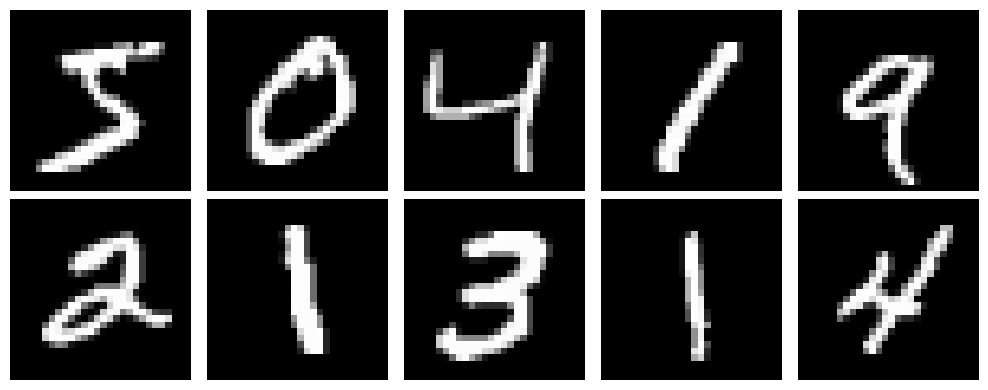

In [26]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [28]:
print("Minimum Pixel Value:", x_train.min())
print("Maximum Pixel Value:", x_train.max())

Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


In [29]:
x_train_clean = np.expand_dims(x_train, axis=-1)
x_test_clean = np.expand_dims(x_test, axis=-1)

print(x_train_clean.shape)
print(x_test_clean.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [30]:
noise_factor = 0.4

np.random.seed(42)

x_train_noisy = x_train_clean + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train_clean.shape
)

x_test_noisy = x_test_clean + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test_clean.shape
)

In [31]:
x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

In [32]:
x_train_noisy = x_train_noisy.astype("float32")
x_test_noisy = x_test_noisy.astype("float32")

In [33]:
print("Clean Training Shape:", x_train_clean.shape)
print("Noisy Training Shape:", x_train_noisy.shape)

print("Clean Testing Shape:", x_test_clean.shape)
print("Noisy Testing Shape:", x_test_noisy.shape)

Clean Training Shape: (60000, 28, 28, 1)
Noisy Training Shape: (60000, 28, 28, 1)
Clean Testing Shape: (10000, 28, 28, 1)
Noisy Testing Shape: (10000, 28, 28, 1)


In [34]:
print("Noisy Minimum:", x_train_noisy.min())
print("Noisy Maximum:", x_train_noisy.max())

Noisy Minimum: 0.0
Noisy Maximum: 1.0


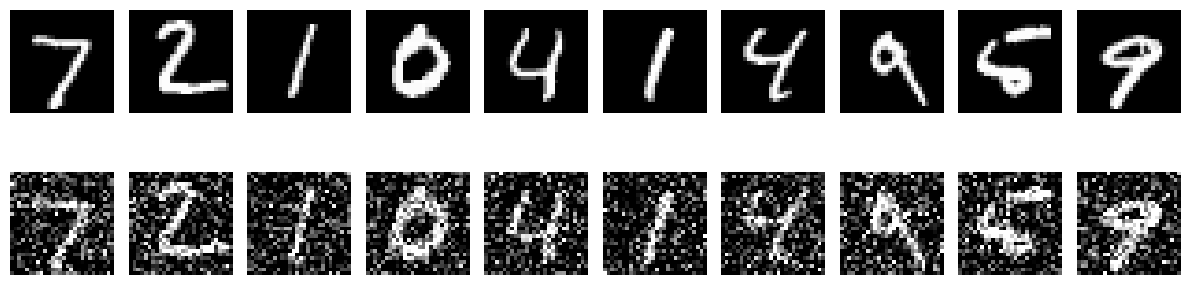

In [35]:
plt.figure(figsize=(12, 4))

for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test_clean[i].squeeze(), cmap="gray")
    plt.axis("off")

    plt.subplot(2, 10, i + 11)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

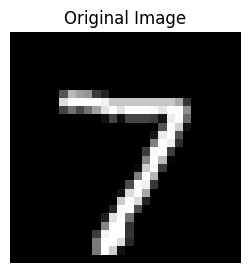

In [36]:
sample_index = 0

plt.figure(figsize=(3, 3))
plt.imshow(x_test_clean[sample_index].squeeze(), cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

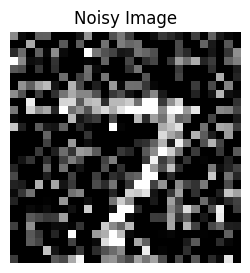

In [37]:
plt.figure(figsize=(3, 3))
plt.imshow(x_test_noisy[sample_index].squeeze(), cmap="gray")
plt.title("Noisy Image")
plt.axis("off")
plt.show()

In [38]:
print("Number of Training Images:", len(x_train_clean))
print("Number of Testing Images:", len(x_test_clean))

Number of Training Images: 60000
Number of Testing Images: 10000


In [39]:
print("Image Height:", x_train_clean.shape[1])
print("Image Width:", x_train_clean.shape[2])
print("Channels:", x_train_clean.shape[3])

Image Height: 28
Image Width: 28
Channels: 1


In [40]:
input_shape = (28, 28, 1)

print("Autoencoder Input Shape:", input_shape)
print("Noise Factor:", noise_factor)

Autoencoder Input Shape: (28, 28, 1)
Noise Factor: 0.4


In [41]:
print("MNIST preprocessing and noise generation completed successfully.")

MNIST preprocessing and noise generation completed successfully.


In [42]:
encoder_input = layers.Input(shape=input_shape)

In [43]:
x = layers.Conv2D(
    32,
    (3, 3),
    activation="relu",
    padding="same"
)(encoder_input)

x = layers.MaxPooling2D(
    (2, 2),
    padding="same"
)(x)

In [44]:
x = layers.Conv2D(
    64,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

x = layers.MaxPooling2D(
    (2, 2),
    padding="same"
)(x)

In [45]:
x = layers.Conv2D(
    128,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

In [46]:
encoded = layers.MaxPooling2D(
    (2, 2),
    padding="same",
    name="bottleneck"
)(x)

In [47]:
encoder = models.Model(
    encoder_input,
    encoded,
    name="Encoder"
)

encoder.summary()

Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (MaxPooling2D)       │ (None, 4, 4, 128)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,672 (362.00 KB)

 Trainable params: 92,672 (362.00 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
print("Encoder Input Shape:", encoder.input_shape)
print("Bottleneck Shape:", encoder.output_shape)

Encoder Input Shape: (None, 28, 28, 1)
Bottleneck Shape: (None, 4, 4, 128)


In [49]:
x = layers.Conv2D(
    128,
    (3, 3),
    activation="relu",
    padding="same"
)(encoded)

x = layers.UpSampling2D((2, 2))(x)

In [50]:
x = layers.Conv2D(
    64,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

x = layers.UpSampling2D((2, 2))(x)

In [51]:
x = layers.Conv2D(
    32,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

x = layers.UpSampling2D((2, 2))(x)

In [52]:
x = layers.Conv2D(
    16,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

In [53]:
decoded = layers.Conv2D(
    1,
    (3, 3),
    activation="sigmoid",
    padding="same"
)(x)

In [54]:
decoded = layers.Cropping2D(
    cropping=((2, 2), (2, 2))
)(decoded)

In [55]:
autoencoder = models.Model(
    encoder_input,
    decoded,
    name="MNIST_Denoising_Autoencoder"
)

autoencoder.summary()

Model: "MNIST_Denoising_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (MaxPooling2D)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 1)      │           145 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d (Cropping2D)         │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337,281 (1.29 MB)

 Trainable params: 337,281 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

In [56]:
print("Autoencoder Input Shape:", autoencoder.input_shape)
print("Autoencoder Output Shape:", autoencoder.output_shape)

Autoencoder Input Shape: (None, 28, 28, 1)
Autoencoder Output Shape: (None, 28, 28, 1)


In [57]:
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["mse"]
)

In [58]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [59]:
checkpoint = ModelCheckpoint(
    "best_mnist_autoencoder.keras",
    monitor="val_loss",
    save_best_only=True
)

In [60]:
print("Input:", x_train_noisy.shape)
print("Target:", x_train_clean.shape)
print("Model Output:", autoencoder.output_shape)

Input: (60000, 28, 28, 1)
Target: (60000, 28, 28, 1)
Model Output: (None, 28, 28, 1)


In [61]:
print("Convolutional Autoencoder created and compiled successfully.")

Convolutional Autoencoder created and compiled successfully.


In [62]:
history = autoencoder.fit(
    x_train_noisy,
    x_train_clean,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test_clean),
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 354s 740ms/step - loss: 0.1587 - mse: 0.0318 - val_loss: 0.1071 - val_mse: 0.0148
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 346s 737ms/step - loss: 0.1016 - mse: 0.0129 - val_loss: 0.0960 - val_mse: 0.0112
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 344s 733ms/step - loss: 0.0947 - mse: 0.0106 - val_loss: 0.0923 - val_mse: 0.0100
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 374s 717ms/step - loss: 0.0916 - mse: 0.0097 - val_loss: 0.0909 - val_mse: 0.0096
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 390s 735ms/step - loss: 0.0898 - mse: 0.0091 - val_loss: 0.0890 - val_mse: 0.0089
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 383s 736ms/step - loss: 0.0884 - mse: 0.0086 - val_loss: 0.0878 - val_mse: 0.0085
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 342s 729ms/step - loss: 0.0874 - mse: 0.0083 - val_loss: 0.0872 - val_mse: 0.0084
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 346s 738ms/step - loss: 0.0868 - mse: 0.0081 - val_loss: 0.0861 - val_mse: 0.0080
Epoch 9/20
469/469 ━━━━━

In [63]:
print("Training Completed Successfully")
print("Epochs Trained:", len(history.history["loss"]))

Training Completed Successfully
Epochs Trained: 20


In [64]:
test_loss, test_mse = autoencoder.evaluate(
    x_test_noisy,
    x_test_clean,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test MSE:", test_mse)

Test Loss: 0.08376193046569824
Test MSE: 0.007316278293728828


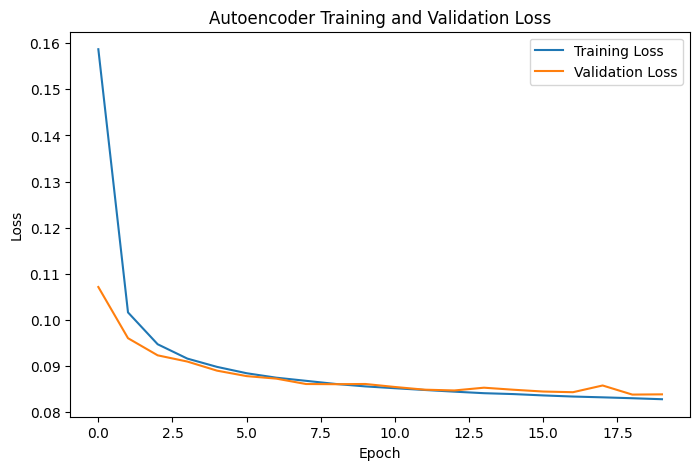

In [65]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training and Validation Loss")
plt.legend()

plt.show()

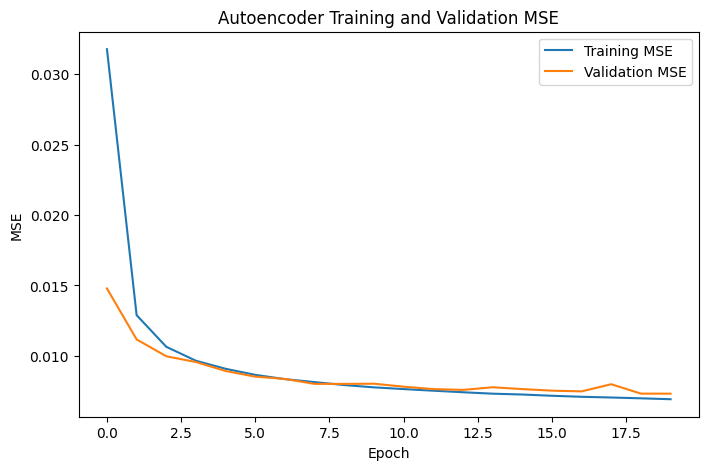

In [66]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["mse"], label="Training MSE")
plt.plot(history.history["val_mse"], label="Validation MSE")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Autoencoder Training and Validation MSE")
plt.legend()

plt.show()

In [67]:
denoised_images = autoencoder.predict(
    x_test_noisy,
    verbose=1
)

print(denoised_images.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step
(10000, 28, 28, 1)


In [68]:
denoised_images = np.clip(
    denoised_images,
    0.0,
    1.0
)

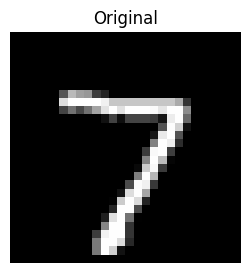

In [69]:
sample_index = 0

plt.figure(figsize=(3, 3))
plt.imshow(
    x_test_clean[sample_index].squeeze(),
    cmap="gray"
)
plt.title("Original")
plt.axis("off")
plt.show()

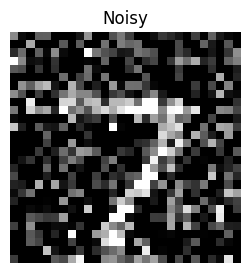

In [70]:
plt.figure(figsize=(3, 3))
plt.imshow(
    x_test_noisy[sample_index].squeeze(),
    cmap="gray"
)
plt.title("Noisy")
plt.axis("off")
plt.show()

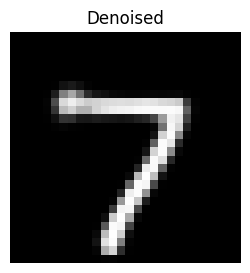

In [71]:
plt.figure(figsize=(3, 3))
plt.imshow(
    denoised_images[sample_index].squeeze(),
    cmap="gray"
)
plt.title("Denoised")
plt.axis("off")
plt.show()

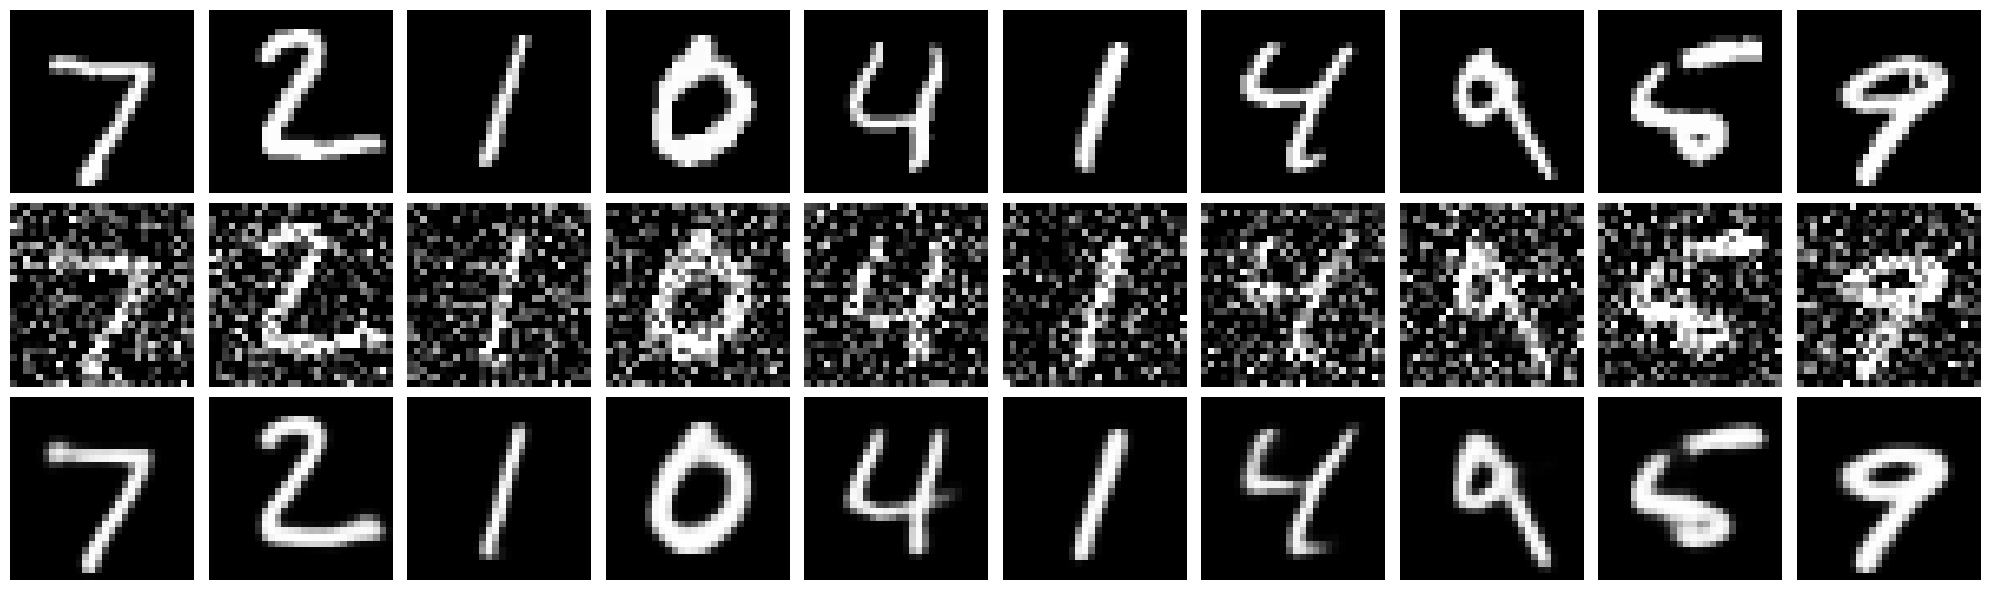

In [72]:
n = 10

plt.figure(figsize=(20, 6))

for i in range(n):

    plt.subplot(3, n, i + 1)
    plt.imshow(x_test_clean[i].squeeze(), cmap="gray")
    plt.axis("off")

    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray")
    plt.axis("off")

    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(denoised_images[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [73]:
original_mse = np.mean(
    (x_test_clean - x_test_noisy) ** 2
)

denoised_mse = np.mean(
    (x_test_clean - denoised_images) ** 2
)

print("Noisy Image MSE:", original_mse)
print("Denoised Image MSE:", denoised_mse)

Noisy Image MSE: 0.07956595
Denoised Image MSE: 0.007316279


In [74]:
mse_improvement = (
    (original_mse - denoised_mse)
    / original_mse
) * 100

print("MSE Improvement:", mse_improvement, "%")

MSE Improvement: 90.80476 %


In [75]:
noisy_psnr = tf.image.psnr(
    x_test_clean,
    x_test_noisy,
    max_val=1.0
)

denoised_psnr = tf.image.psnr(
    x_test_clean,
    denoised_images,
    max_val=1.0
)

In [76]:
print(
    "Average Noisy PSNR:",
    float(tf.reduce_mean(noisy_psnr))
)

print(
    "Average Denoised PSNR:",
    float(tf.reduce_mean(denoised_psnr))
)

Average Noisy PSNR: 11.004463195800781
Average Denoised PSNR: 21.74305534362793


In [77]:
encoded_images = encoder.predict(
    x_test_noisy[:10],
    verbose=0
)

print("Original Image Shape:", x_test_noisy[:10].shape)
print("Encoded Representation Shape:", encoded_images.shape)

Original Image Shape: (10, 28, 28, 1)
Encoded Representation Shape: (10, 4, 4, 128)


In [78]:
best_autoencoder = tf.keras.models.load_model(
    "best_mnist_autoencoder.keras"
)

print("Best Model Loaded Successfully")

Best Model Loaded Successfully


In [79]:
best_test_loss, best_test_mse = best_autoencoder.evaluate(
    x_test_noisy,
    x_test_clean,
    verbose=0
)

print("Best Model Test Loss:", best_test_loss)
print("Best Model Test MSE:", best_test_mse)

Best Model Test Loss: 0.08376193046569824
Best Model Test MSE: 0.007316278293728828


In [80]:
best_denoised_images = best_autoencoder.predict(
    x_test_noisy,
    verbose=0
)

best_denoised_images = np.clip(
    best_denoised_images,
    0.0,
    1.0
)

In [81]:
print("Training, Evaluation and Denoising Completed Successfully")

Training, Evaluation and Denoising Completed Successfully


In [82]:
final_denoised = best_autoencoder.predict(
    x_test_noisy,
    verbose=0
)

final_denoised = np.clip(
    final_denoised,
    0.0,
    1.0
)

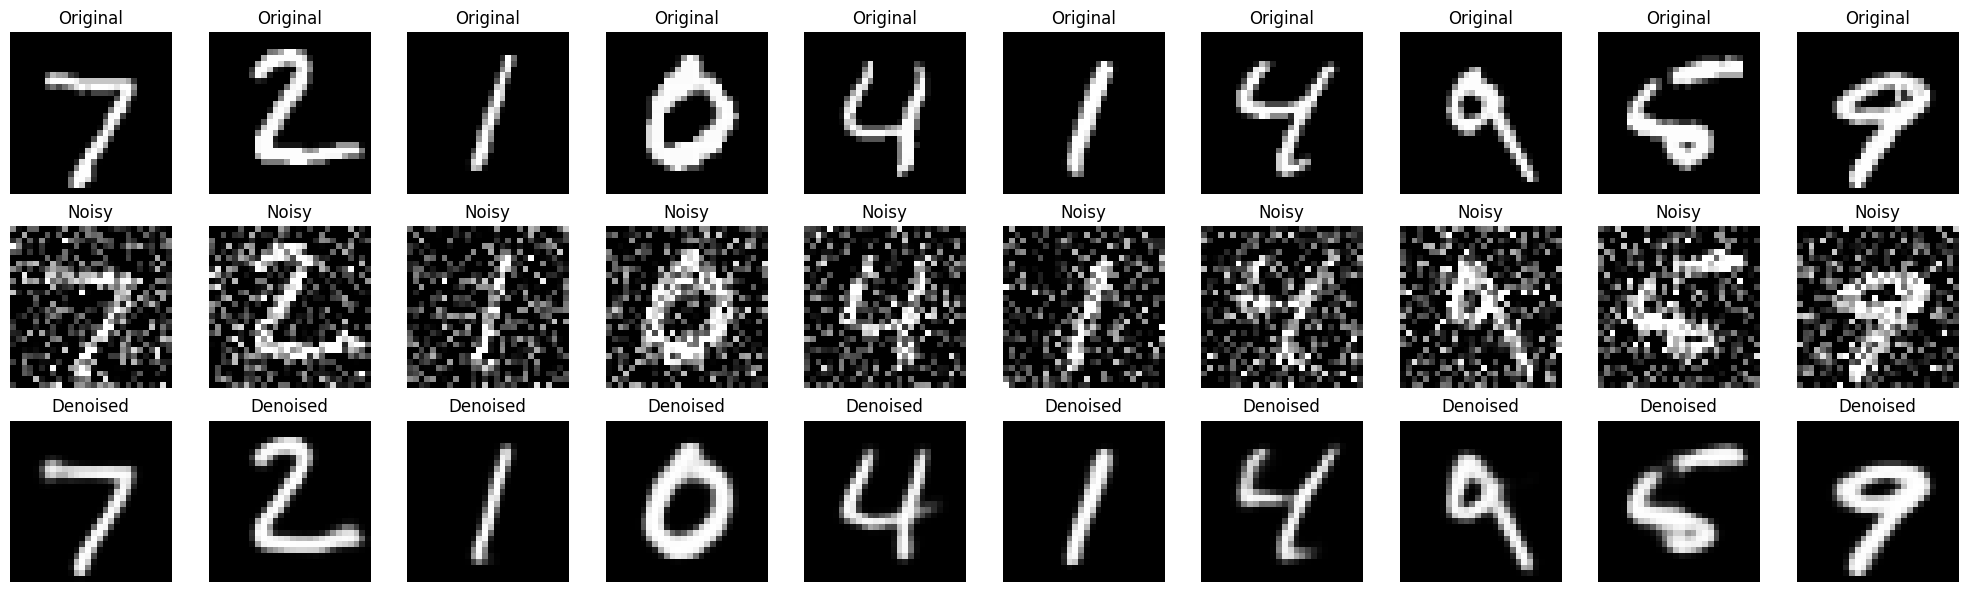

In [83]:
n = 10

plt.figure(figsize=(20, 6))

for i in range(n):

    plt.subplot(3, n, i + 1)
    plt.imshow(x_test_clean[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(final_denoised[i].squeeze(), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [84]:
noisy_mse = np.mean(
    (x_test_clean - x_test_noisy) ** 2
)

final_mse = np.mean(
    (x_test_clean - final_denoised) ** 2
)

print("Noisy MSE:", noisy_mse)
print("Denoised MSE:", final_mse)

Noisy MSE: 0.07956595
Denoised MSE: 0.007316279


In [85]:
improvement = (
    (noisy_mse - final_mse)
    / noisy_mse
) * 100

print("MSE Improvement:", round(improvement, 2), "%")

MSE Improvement: 90.8 %


In [86]:
noisy_psnr_final = tf.image.psnr(
    x_test_clean,
    x_test_noisy,
    max_val=1.0
)

denoised_psnr_final = tf.image.psnr(
    x_test_clean,
    final_denoised,
    max_val=1.0
)

avg_noisy_psnr = float(
    tf.reduce_mean(noisy_psnr_final)
)

avg_denoised_psnr = float(
    tf.reduce_mean(denoised_psnr_final)
)

print("Noisy PSNR:", avg_noisy_psnr)
print("Denoised PSNR:", avg_denoised_psnr)

Noisy PSNR: 11.004463195800781
Denoised PSNR: 21.74305534362793


In [87]:
metrics = ["MSE", "PSNR"]

noisy_scores = [
    noisy_mse,
    avg_noisy_psnr
]

denoised_scores = [
    final_mse,
    avg_denoised_psnr
]

print("Metrics:", metrics)
print("Noisy:", noisy_scores)
print("Denoised:", denoised_scores)

Metrics: ['MSE', 'PSNR']
Noisy: [np.float32(0.07956595), 11.004463195800781]
Denoised: [np.float32(0.007316279), 21.74305534362793]


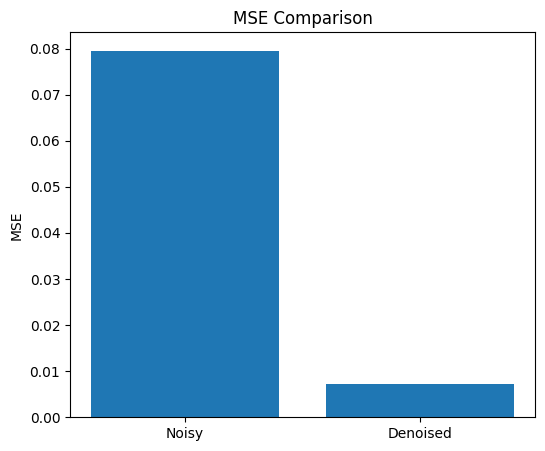

In [88]:
plt.figure(figsize=(6, 5))

plt.bar(
    ["Noisy", "Denoised"],
    [noisy_mse, final_mse]
)

plt.ylabel("MSE")
plt.title("MSE Comparison")

plt.show()

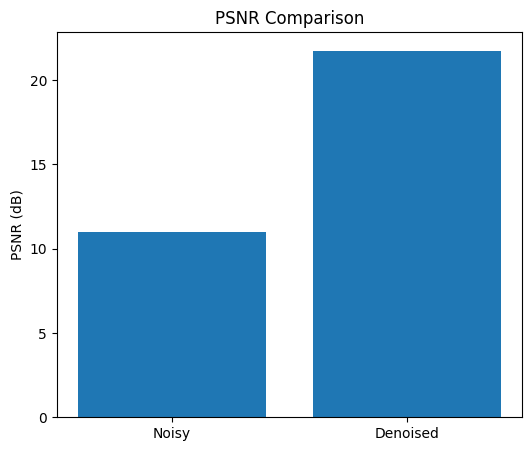

In [89]:
plt.figure(figsize=(6, 5))

plt.bar(
    ["Noisy", "Denoised"],
    [avg_noisy_psnr, avg_denoised_psnr]
)

plt.ylabel("PSNR (dB)")
plt.title("PSNR Comparison")

plt.show()

In [90]:
random_index = np.random.randint(
    0,
    len(x_test_clean)
)

print("Selected Image Index:", random_index)

Selected Image Index: 6339


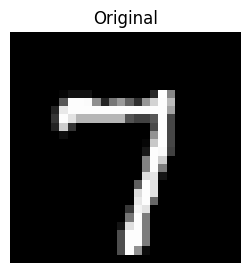

In [91]:
plt.figure(figsize=(3, 3))

plt.imshow(
    x_test_clean[random_index].squeeze(),
    cmap="gray"
)

plt.title("Original")
plt.axis("off")

plt.show()

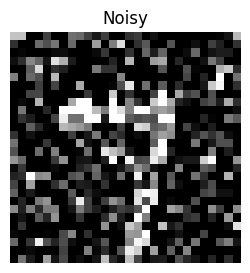

In [92]:
plt.figure(figsize=(3, 3))

plt.imshow(
    x_test_noisy[random_index].squeeze(),
    cmap="gray"
)

plt.title("Noisy")
plt.axis("off")

plt.show()

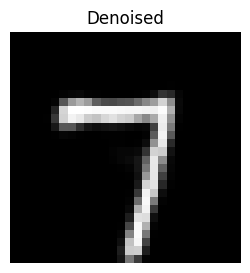

In [93]:
plt.figure(figsize=(3, 3))

plt.imshow(
    final_denoised[random_index].squeeze(),
    cmap="gray"
)

plt.title("Denoised")
plt.axis("off")

plt.show()

In [94]:
autoencoder.save(
    "MNIST_Denoising_Autoencoder.keras"
)

print("Autoencoder Saved Successfully")

Autoencoder Saved Successfully


In [95]:
encoder.save(
    "MNIST_Encoder.keras"
)

print("Encoder Saved Successfully")

Encoder Saved Successfully


In [96]:
loaded_autoencoder = tf.keras.models.load_model(
    "MNIST_Denoising_Autoencoder.keras"
)

print("Saved Autoencoder Loaded Successfully")

Saved Autoencoder Loaded Successfully


In [97]:
loaded_prediction = loaded_autoencoder.predict(
    x_test_noisy[:1],
    verbose=0
)

print("Prediction Shape:", loaded_prediction.shape)

Prediction Shape: (1, 28, 28, 1)


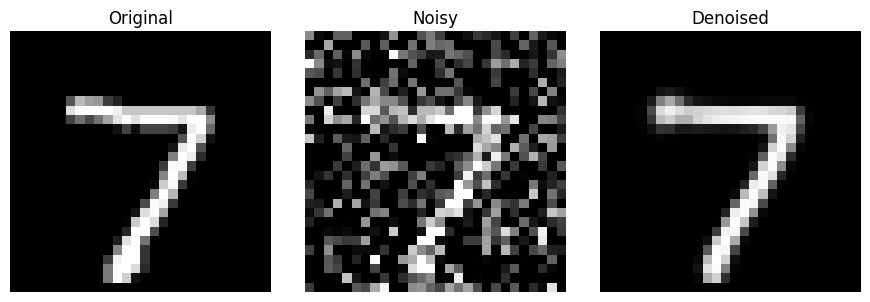

In [98]:
plt.figure(figsize=(9, 3))

plt.subplot(1, 3, 1)
plt.imshow(x_test_clean[0].squeeze(), cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(x_test_noisy[0].squeeze(), cmap="gray")
plt.title("Noisy")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(loaded_prediction[0].squeeze(), cmap="gray")
plt.title("Denoised")
plt.axis("off")

plt.tight_layout()
plt.show()

In [99]:
from google.colab import files

files.download(
    "MNIST_Denoising_Autoencoder.keras"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [100]:
print("Final Test MSE:", final_mse)
print("MSE Improvement:", round(improvement, 2), "%")
print("Noisy PSNR:", round(avg_noisy_psnr, 2), "dB")
print("Denoised PSNR:", round(avg_denoised_psnr, 2), "dB")
print("MNIST Image Denoising Project Completed Successfully")

Final Test MSE: 0.007316279
MSE Improvement: 90.8 %
Noisy PSNR: 11.0 dB
Denoised PSNR: 21.74 dB
MNIST Image Denoising Project Completed Successfully


# Conclusion

In this project, I worked with the MNIST dataset and built a convolutional autoencoder to clean noisy handwritten digit images. I added some random noise to the original images and trained the model to convert those noisy images back into cleaner ones.

The model mainly works in two parts. The encoder picks out the important features from the image, while the decoder uses those features to rebuild the image. After training, I could clearly see that the reconstructed images had much less noise compared to the input images.

I also checked the performance using MSE and PSNR. The results showed that the quality of the images improved after passing through the autoencoder.

Overall, this project helped me understand how autoencoders actually work and how they can be used to remove noise and reconstruct images using deep learning.